# Assignment: More Matplotlib

## Problem 1: Line plots

In [3]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

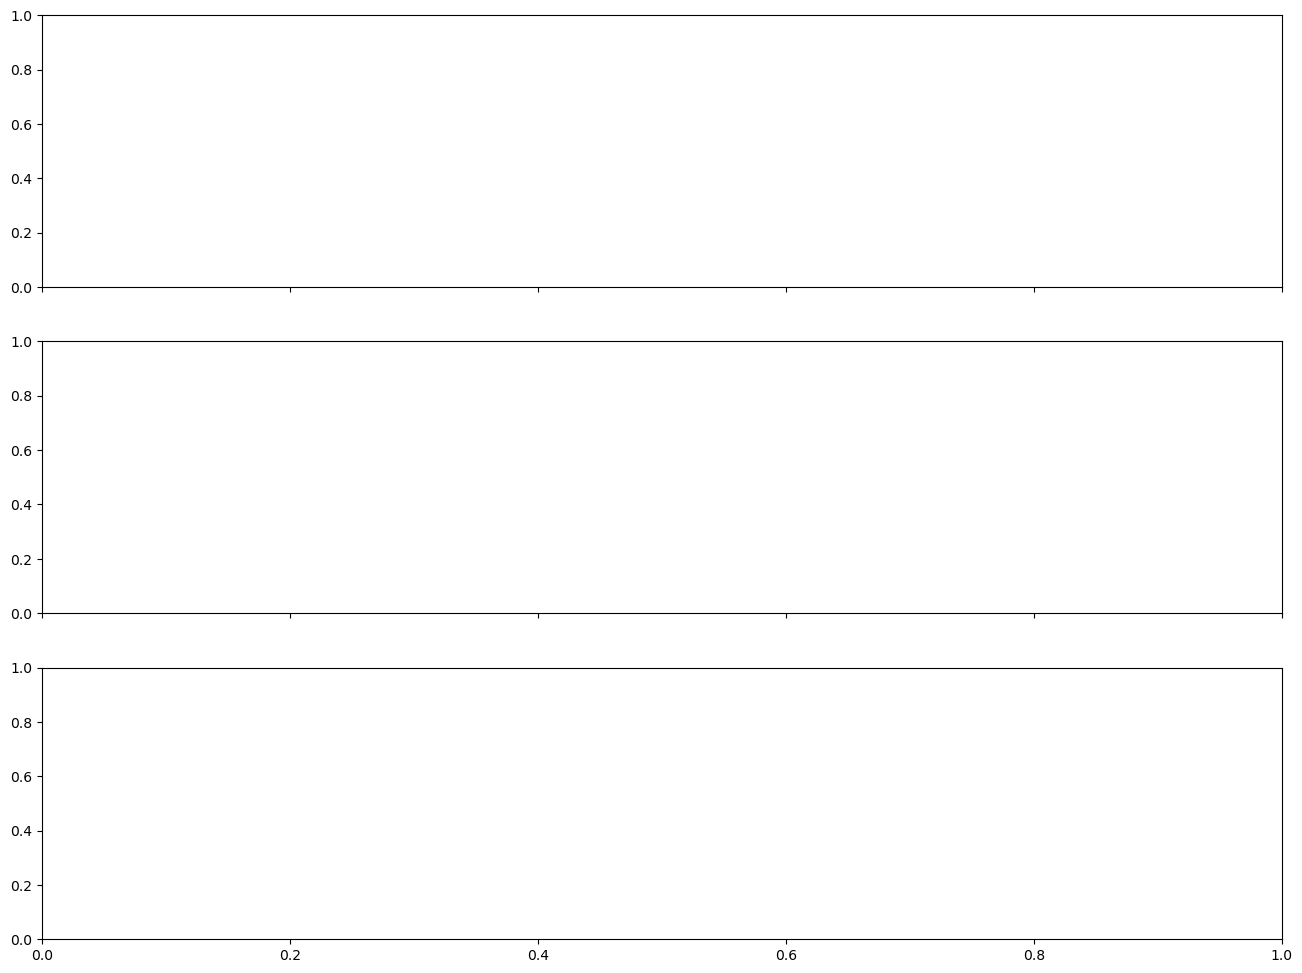

In [4]:
import numpy as np
from matplotlib import pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 12), sharex=True)
ax0, ax1, ax2 = axes

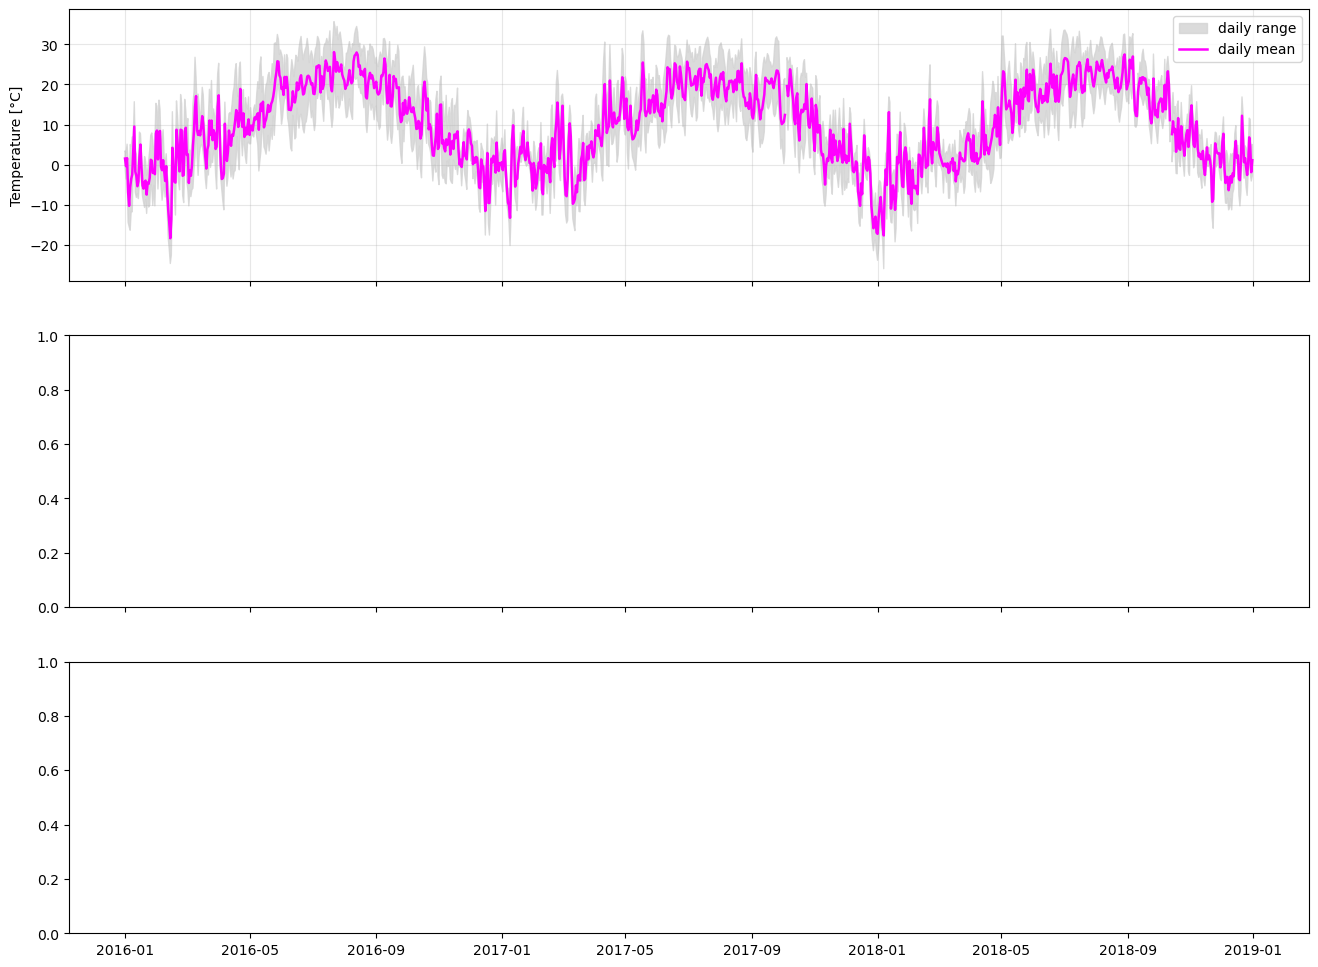

In [5]:
ax0.fill_between(date, t_daily_min, t_daily_max,
                 color='lightgray', alpha=0.8, label='daily range')
ax0.plot(date, t_daily_mean,
         color='magenta', linewidth=1.8, label='daily mean')
ax0.set_ylabel('Temperature [°C]')
ax0.legend(loc='upper right')
ax0.grid(True, alpha=0.3)

fig

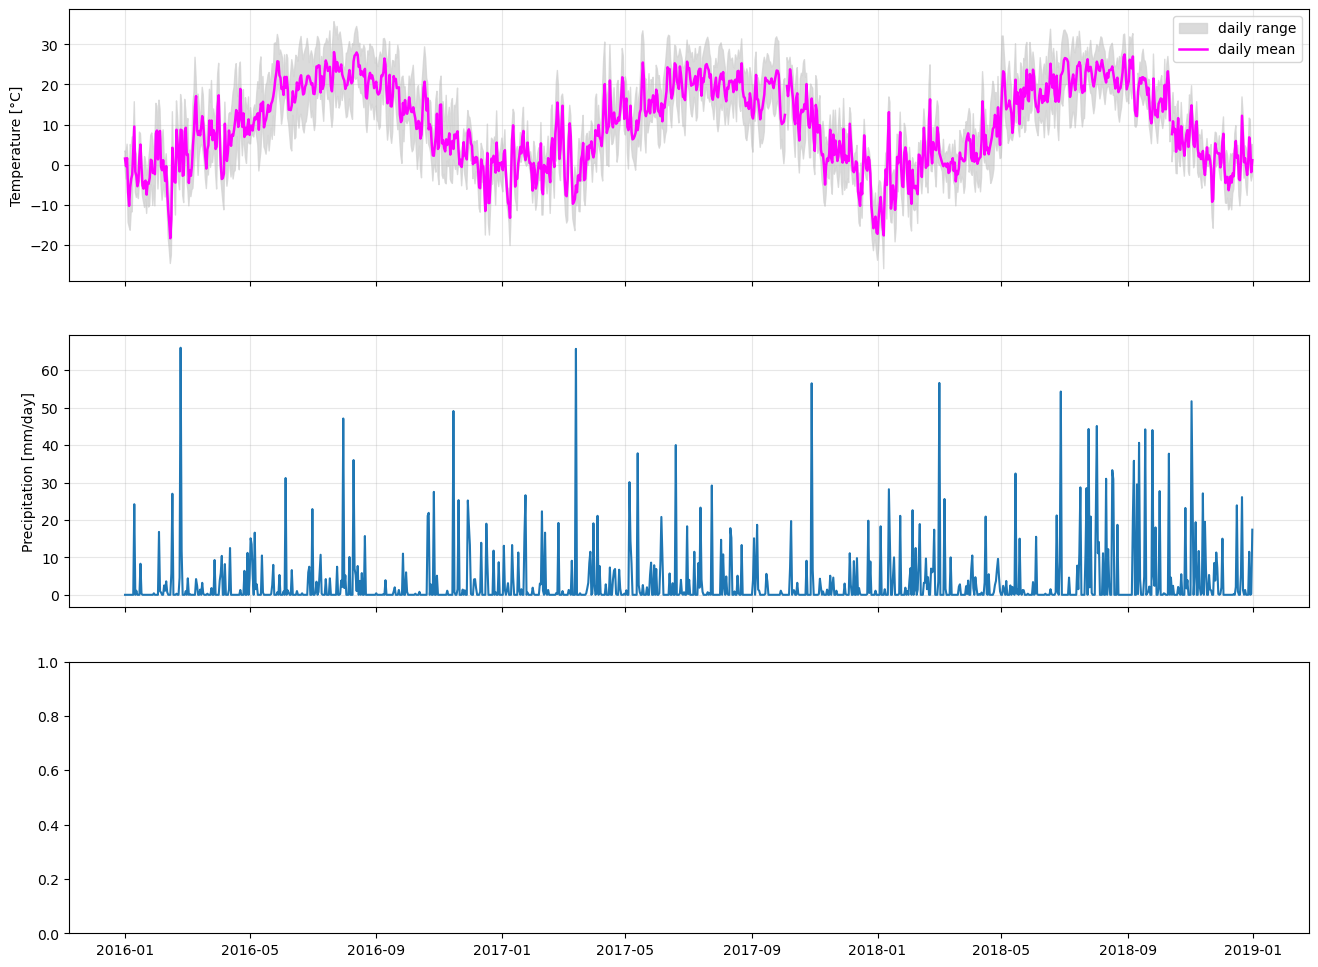

In [6]:
ax1.plot(date, p_daily_calc, color='C0', linewidth=1.5)
ax1.set_ylabel('Precipitation [mm/day]')
ax1.grid(True, alpha=0.3)

fig

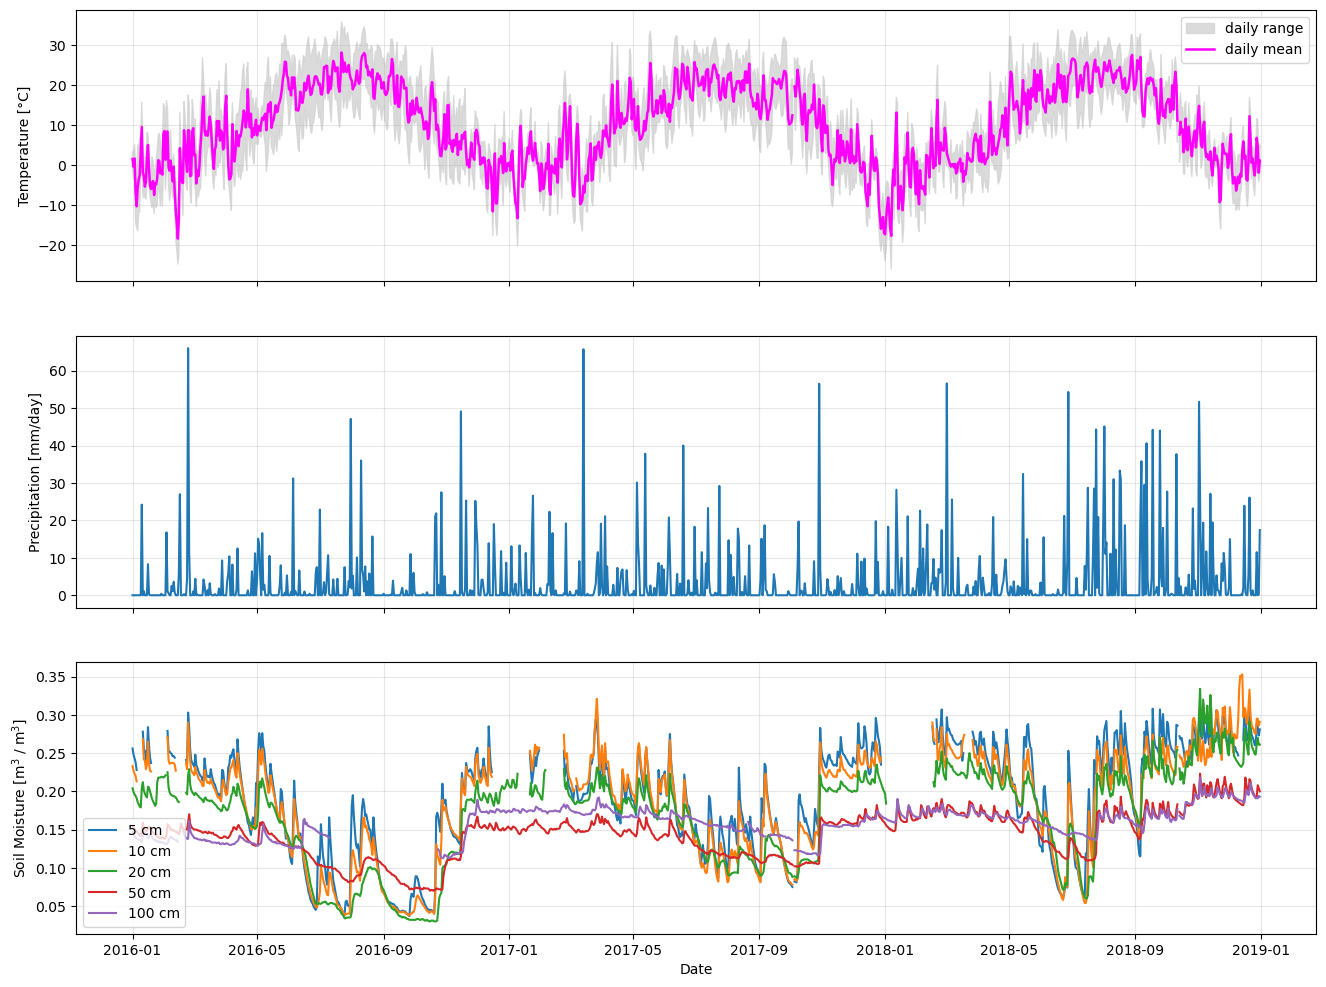

<Figure size 640x480 with 0 Axes>

In [7]:
ax2.plot(date, soil_moisture_5, label='5 cm')
ax2.plot(date, soil_moisture_10, label='10 cm')
ax2.plot(date, soil_moisture_20, label='20 cm')
ax2.plot(date, soil_moisture_50, label='50 cm')
ax2.plot(date, soil_moisture_100, label='100 cm')
ax2.set_ylabel('Soil Moisture [m$^3$ / m$^3$]')
ax2.set_xlabel('Date')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig

## Problem 2: Contour Plots

In [11]:
import sys
!{sys.executable} -m pip install --user pydap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.6 MB/s  0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 3/4 [pydap]  WARNING: The scripts dods and pydap are installed in '/home/wt2394/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pydap]


In [1]:
import pydap
print(pydap.__version__)

3.5.8


In [3]:
import xarray as xr

ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, engine='pydap', decode_times=False)

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

/home/wt2394/.local/lib/python3.11/site-packages/pydap/handlers/dap.py:143: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


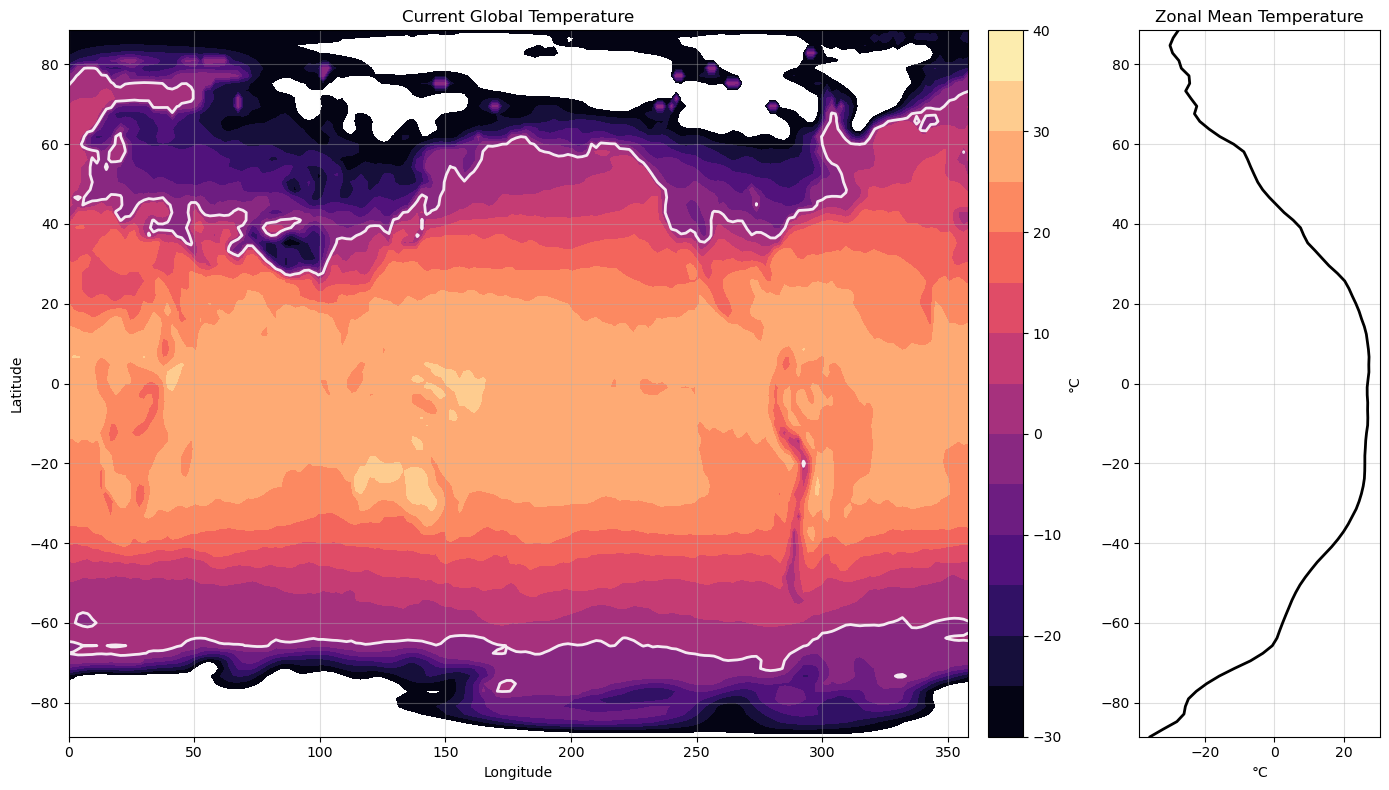

In [20]:
import numpy as np
from matplotlib import pyplot as plt

zonal_mean = np.mean(temp, axis=1)

fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(14, 8),
    gridspec_kw={'width_ratios': [4, 1]}
)
ax0, ax1 = axes

levels = np.arange(-30, 45, 5)
cf = ax0.contourf(lon, lat, temp, levels=levels, cmap='magma')

ax0.contour(lon, lat, temp,
            levels=[0],
            colors='white', linewidths=2, alpha=0.9)

ax0.set_title('Current Global Temperature')
ax0.set_xlabel('Longitude')
ax0.set_ylabel('Latitude')
ax0.grid(True, alpha=0.4)

cbar = fig.colorbar(cf, ax=ax0, fraction=0.046, pad=0.02)
cbar.set_label('°C')

ax1.plot(zonal_mean, lat, color='black', linewidth=2)
ax1.set_title('Zonal Mean Temperature')
ax1.set_xlabel('°C')
ax1.grid(True, alpha=0.4)
ax1.set_ylim(lat.min(), lat.max())

fig.tight_layout()
plt.show()

## Problem 3: Scatter plots

In [24]:
import pooch
import numpy as np
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

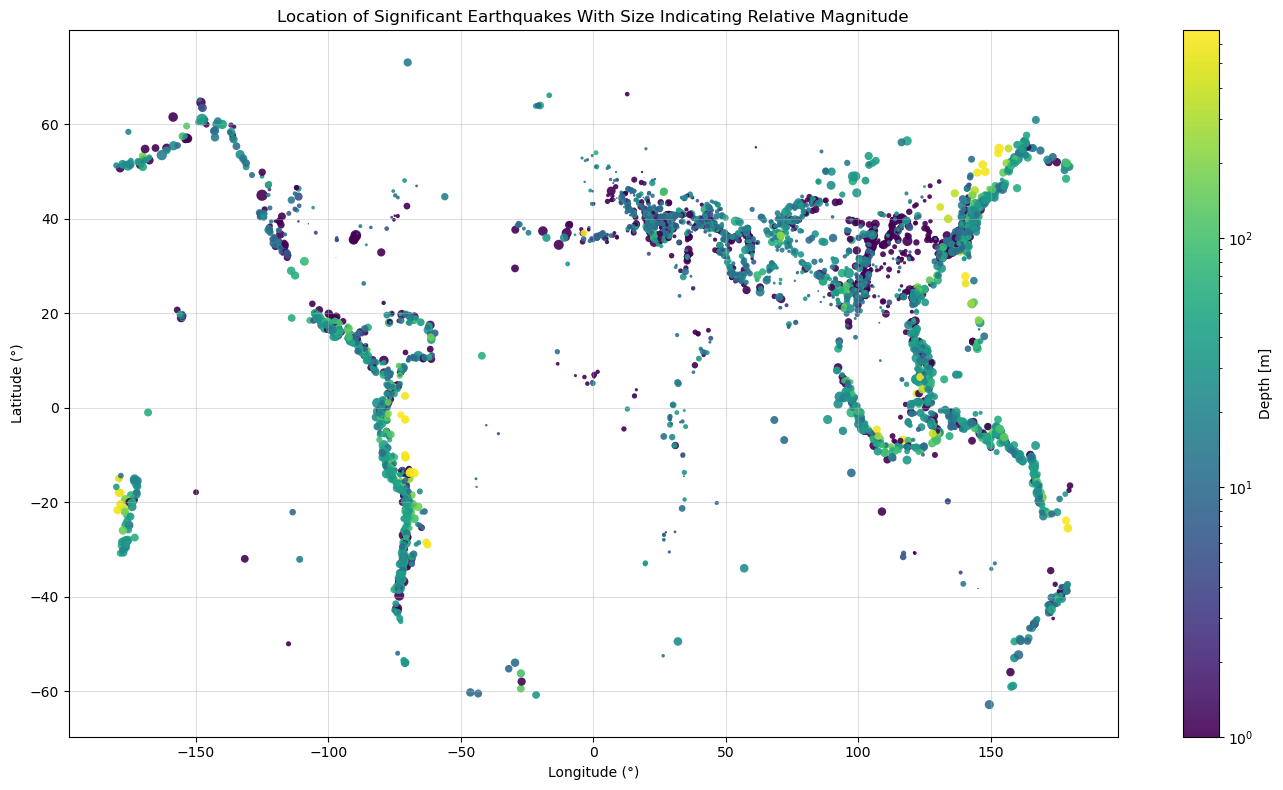

In [28]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

depth_plot = np.where(depth > 0, depth, 1)

marker_size = magnitude**4 / 100

fig, ax = plt.subplots(figsize=(14, 8))

sc = ax.scatter(longitude, latitude,
                c=depth_plot,
                s=marker_size,
                cmap='viridis',
                norm=LogNorm(),
                alpha=0.9,
                edgecolors='none')

ax.set_title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.grid(True, alpha=0.4)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Depth [m]')

plt.tight_layout()
plt.show()